<a href="https://colab.research.google.com/github/emurlu024/UTokyo-Muon-DataAnalysis/blob/main/Run2_AX20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

First Configuration
*   Small sensor horizontal
*   Larger sensor vertical
*   Small sensor stacked ontop of the larger sensor
*   1cm gap in between

10.39.47 Minute run time

Files Included:
1.   run2.txt
2.   AxLab_C_020.txt

Upload the Run 2 and AX 020 text files.


Saving AxLab_C_020.txt to AxLab_C_020.txt
Saving run2.txt to run2.txt
Run 2 file: run2.txt
AX 020 file: AxLab_C_020.txt


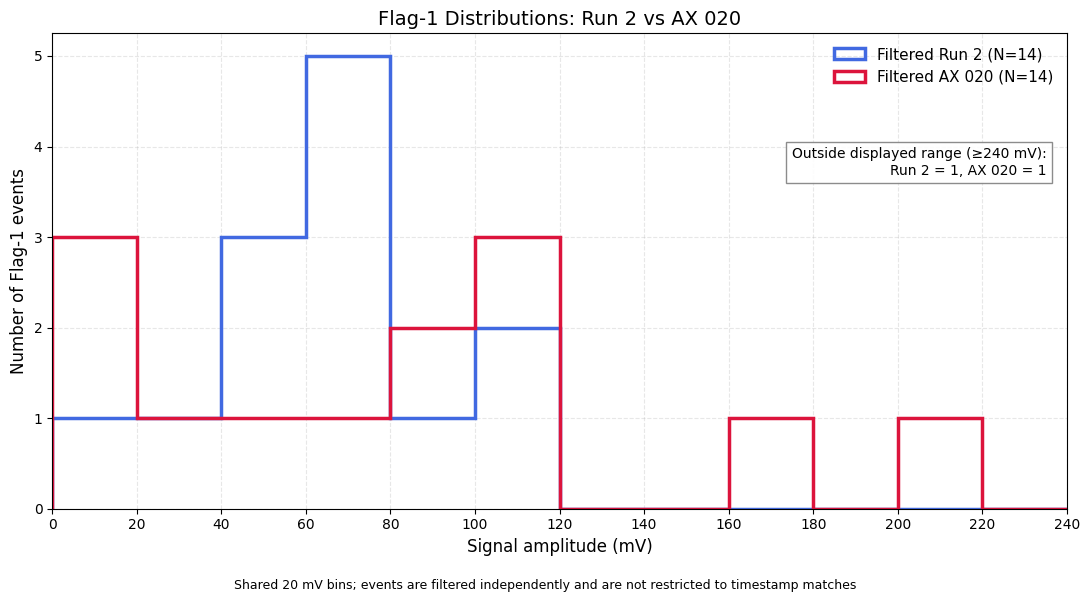


Summary
-------------------------------------------
Run 2 Flag-1 events: 14
Run 2 median signal: 66.4 mV
Run 2 mean signal: 133.2 mV

AX 020 Flag-1 events: 14
AX 020 median signal: 96.1 mV
AX 020 mean signal: 148.2 mV


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

#1. Find or upload the two data files ------------------------------------------------------------

def find_data_files():
    """Find Run 2 and AX 020 text files in the Colab workspace."""

    txt_files = list(Path(".").glob("*.txt"))

    run_candidates = [
        path for path in txt_files
        if "run2" in path.name.lower()
        .replace("_", "")
        .replace("-", "")
        .replace(" ", "")
        and "axlab" not in path.name.lower()
    ]

    ax_candidates = [
        path for path in txt_files
        if "020" in path.name.lower()
    ]

    return run_candidates, ax_candidates


run_candidates, ax_candidates = find_data_files()

#Asking for uploads if the files are not already in Colab
if not run_candidates or not ax_candidates:
    try:
        from google.colab import files

        print("Upload the Run 2 and AX 020 text files.")
        files.upload()

        run_candidates, ax_candidates = find_data_files()

    except ImportError:
        print("This is not running in Google Colab.")


if not run_candidates:
    raise FileNotFoundError(
        "Run 2 file was not found. Upload filtered_run2.txt or run2(1).txt."
    )

if not ax_candidates:
    raise FileNotFoundError(
        "AX 020 file was not found. Upload filtered_AxLab_C_020.txt "
        "or AxLab_C_020(1).txt."
    )


RUN_FILE = run_candidates[0]
AX_FILE = ax_candidates[0]

print(f"Run 2 file: {RUN_FILE.name}")
print(f"AX 020 file: {AX_FILE.name}")

#2. Read the files and select Flag = 1 ------------------------------------------------------------

def load_flag1_sipm(path):
    """
    Read a CosmicWatch text file.

    Comment/header lines beginning with # are ignored.
    Only rows with Flag = 1 are retained.
    The SiPM signal is taken from column 5.
    """

    sipm_values = []

    with open(path, "r", encoding="utf-8") as file:
        for line_number, line in enumerate(file, start=1):

            if not line.strip() or line.lstrip().startswith("#"):
                continue

            fields = line.split()

            if len(fields) < 5:
                print(
                    f"Warning: skipped malformed line "
                    f"{line_number} in {path.name}"
                )
                continue

            flag = fields[2]

            if flag == "1":
                try:
                    sipm_mv = float(fields[4])
                    sipm_values.append(sipm_mv)

                except ValueError:
                    print(
                        f"Warning: invalid SiPM value on "
                        f"line {line_number} in {path.name}"
                    )

    if not sipm_values:
        raise ValueError(f"No Flag-1 events were found in {path.name}.")

    return np.array(sipm_values)


run_signal = load_flag1_sipm(RUN_FILE)
ax_signal = load_flag1_sipm(AX_FILE)

#3. Set the histogram bins ------------------------------------------------------------

plot_limit = 240
bins = np.arange(0, plot_limit + 20, 20)

#4. Create the histogram ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(11, 6))

ax.hist(
    run_signal,
    bins=bins,
    histtype="step",
    linewidth=2.5,
    color="royalblue",
    label=f"Filtered Run 2 (N={len(run_signal)})"
)

ax.hist(
    ax_signal,
    bins=bins,
    histtype="step",
    linewidth=2.5,
    color="crimson",
    label=f"Filtered AX 020 (N={len(ax_signal)})"
)

#5. Count values outside the displayed range ------------------------------------------------------------

run_outside = int(np.sum(run_signal >= plot_limit))
ax_outside = int(np.sum(ax_signal >= plot_limit))

if run_outside > 0 or ax_outside > 0:
    ax.text(
        0.98,
        0.76,
        (
            f"Outside displayed range (≥{plot_limit} mV):\n"
            f"Run 2 = {run_outside}, AX 020 = {ax_outside}"
        ),
        transform=ax.transAxes,
        horizontalalignment="right",
        verticalalignment="top",
        fontsize=10,
        bbox={
            "facecolor": "white",
            "edgecolor": "gray",
            "alpha": 0.9
        }
    )

#6. Labels and formatting ------------------------------------------------------------

ax.set_xlim(0, plot_limit)
ax.set_xticks(np.arange(0, plot_limit + 1, 20))

ax.set_xlabel("Signal amplitude (mV)", fontsize=12)
ax.set_ylabel("Number of Flag-1 events", fontsize=12)

ax.set_title(
    "Flag-1 Distributions: Run 2 vs AX 020",
    fontsize=14
)

ax.grid(
    True,
    linestyle="--",
    alpha=0.3
)

ax.legend(
    fontsize=11,
    frameon=False
)

fig.text(
    0.5,
    0.01,
    (
        "Shared 20 mV bins; events are filtered independently "
        "and are not restricted to timestamp matches"
    ),
    horizontalalignment="center",
    fontsize=9
)

plt.tight_layout(rect=(0, 0.04, 1, 1))

#7. Save and display the graph ------------------------------------------------------------

OUTPUT_FILE = "run2_ax020_flag1_histogram.png"

plt.savefig(
    OUTPUT_FILE,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#8. Print a numerical summary ------------------------------------------------------------

print()
print("Summary")
print("-------------------------------------------")
print(f"Run 2 Flag-1 events: {len(run_signal)}")
print(f"Run 2 median signal: {np.median(run_signal):.1f} mV")
print(f"Run 2 mean signal: {np.mean(run_signal):.1f} mV")
print()
print(f"AX 020 Flag-1 events: {len(ax_signal)}")
print(f"AX 020 median signal: {np.median(ax_signal):.1f} mV")
print(f"AX 020 mean signal: {np.mean(ax_signal):.1f} mV")
#print()
#print(f"Graph saved as: {OUTPUT_FILE}")

#Can remove the # below if you want Colab to download the graph after running

#from google.colab import files
#files.download(OUTPUT_FILE)

#Data Interpretation

**Initial Observation**
*   AX 020 (larger sensor) has a broader visible distribution: signals extend from 8.5 to 218.2 mV
*   Run 2 (smaller sensor) is more concentrated: mainly between 40 and 80 mV
*   AX 020 (larger sensor) generally produced stronger signals: median at 96.1 mV, compared with 66.4 mV for Run 2—a difference of 29.7 mV
*   AX 020 (larger sensor) contains more high-amplitude signals: six of its readings exceed 100 mV, including the 1000 mV value, compared with three for Run 2
*   Both distributions are strongly right-skewed: making the medians more representative of typical signals.
*   Both detectors recorded exactly 14 Flag-1 events
*   Each detector has one 1000 mV reading outside the graph’s 240 mV limit